In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import string
from tqdm import tqdm


In [46]:
df = pd.read_csv('../data/IMDB Dataset.csv')

# Display basic information
print(f"Total number of reviews: {len(df)}")
print("\nFirst few reviews:")
df.head()

Total number of reviews: 50000

First few reviews:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [47]:
# Split the data into training and testing sets
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # This ensures the same proportion of positive/negative reviews in both sets
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("\nTraining set sentiment distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set sentiment distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 40000
Testing set size: 10000

Training set sentiment distribution:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Testing set sentiment distribution:
sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


# Exploratory Data Analysis (EDA)

## Dataset Overview

In [49]:
print(f"Total number of reviews: {len(df)}")
print("\nDataset columns:")
print(df.columns)
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Total number of reviews: 50000

Dataset columns:
Index(['review', 'sentiment'], dtype='object')

Basic statistics:
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000

Missing values:
review       0
sentiment    0
dtype: int64


## Sentiment Distribution Analysis

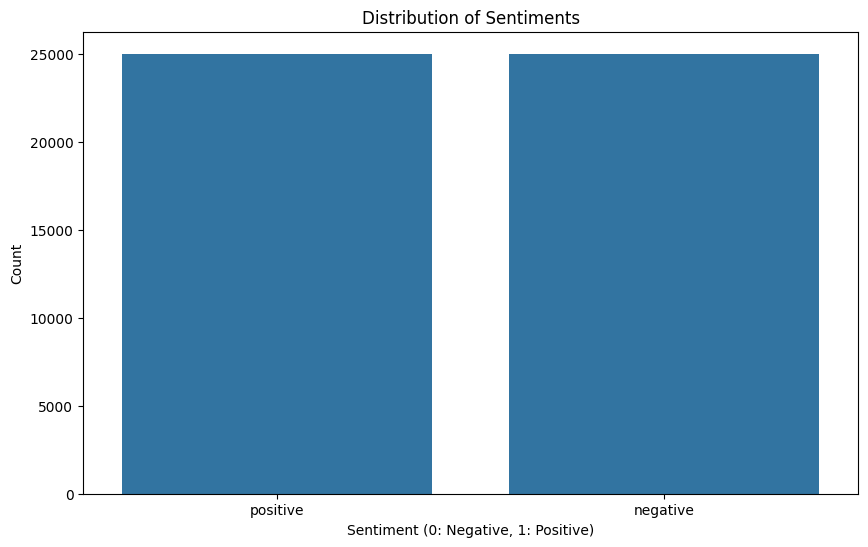


Sentiment Distribution (%):
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [50]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

sentiment_percentages = df['sentiment'].value_counts(normalize=True) * 100
print("\nSentiment Distribution (%):")
print(sentiment_percentages)

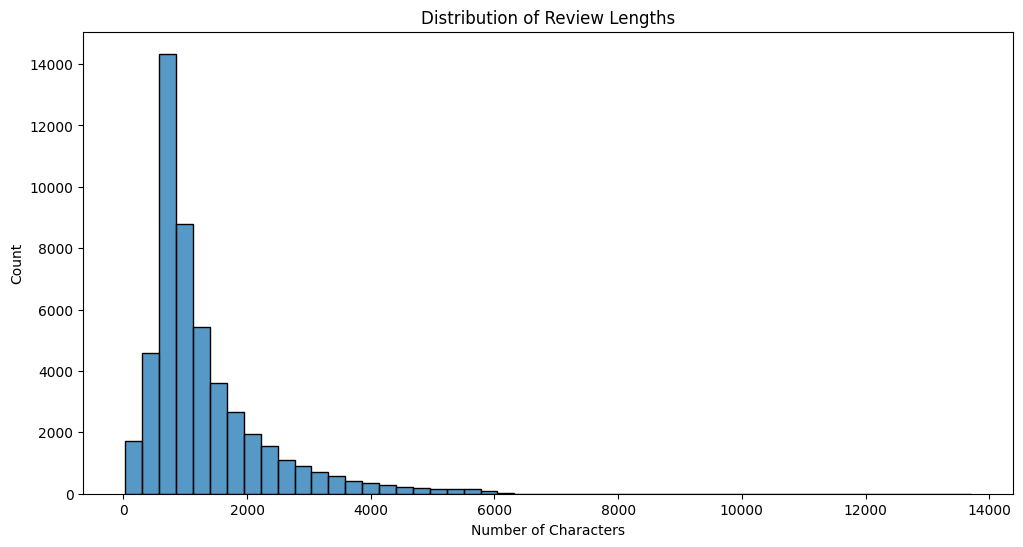


Review Length Statistics by Sentiment:
             count        mean          std   min    25%    50%      75%  \
sentiment                                                                  
negative   25000.0  1294.06436   945.892669  32.0  706.0  973.0  1567.25   
positive   25000.0  1324.79768  1031.492627  65.0  691.0  968.0  1614.00   

               max  
sentiment           
negative    8969.0  
positive   13704.0  


In [51]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='review_length', bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.show()

# Review length statistics by sentiment
print("\nReview Length Statistics by Sentiment:")
print(df.groupby('sentiment')['review_length'].describe())

## Word Count Analysis

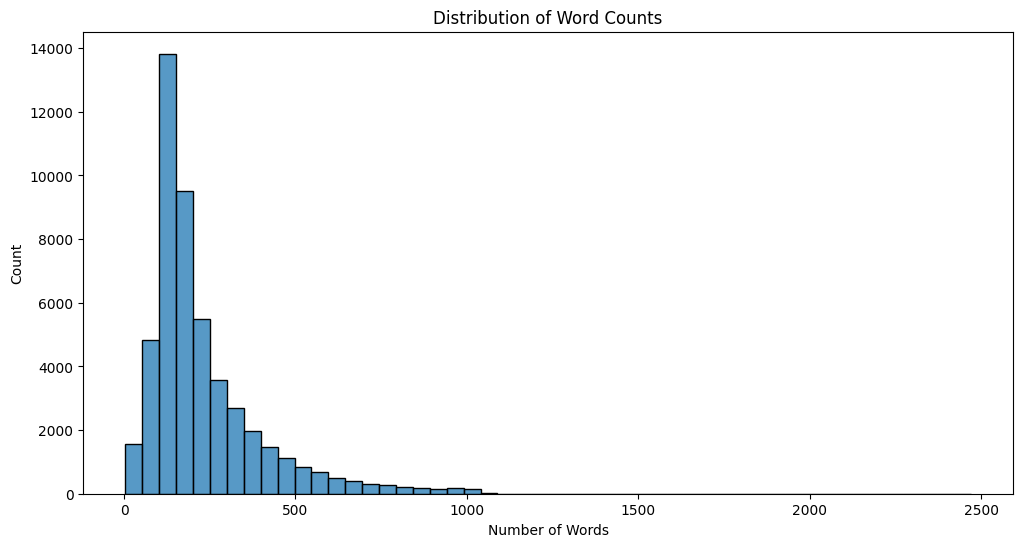


Word Count Statistics by Sentiment:
             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


In [52]:
# Add word count column
df['word_count'] = df['review'].apply(lambda x: len(x.split()))

# Plot word count distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', bins=50)
plt.title('Distribution of Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

# Word count statistics by sentiment
print("\nWord Count Statistics by Sentiment:")
print(df.groupby('sentiment')['word_count'].describe())

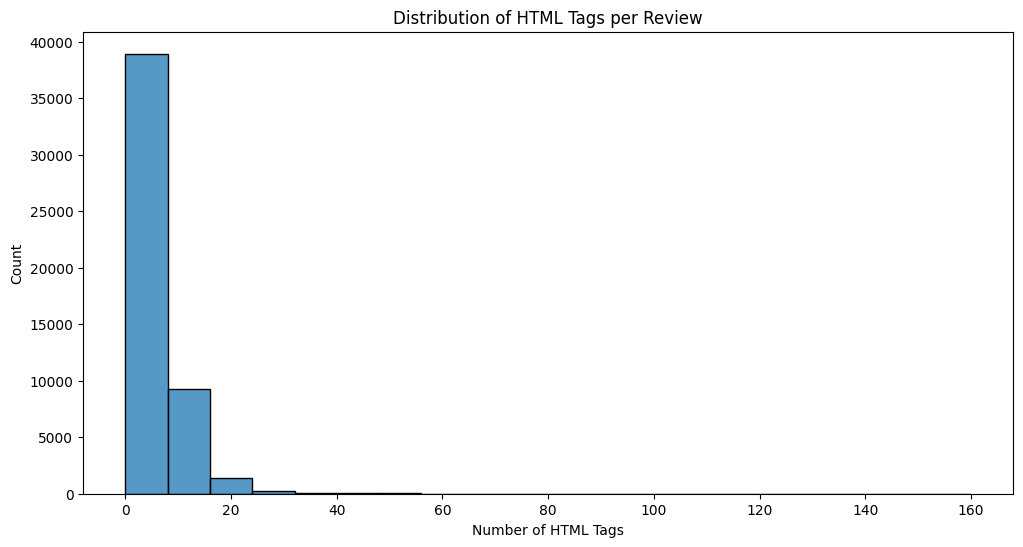


HTML Tag Statistics:
count    50000.00000
mean         4.03964
std          5.34200
min          0.00000
25%          0.00000
50%          2.00000
75%          6.00000
max        160.00000
Name: html_tag_count, dtype: float64


In [53]:
def count_html_tags(text):
    return len(re.findall(r'<[^>]+>', text))

# Add HTML tag count column
df['html_tag_count'] = df['review'].apply(count_html_tags)

# Plot HTML tag distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='html_tag_count', bins=20)
plt.title('Distribution of HTML Tags per Review')
plt.xlabel('Number of HTML Tags')
plt.ylabel('Count')
plt.show()

# HTML tag statistics
print("\nHTML Tag Statistics:")
print(df['html_tag_count'].describe())

## EDA Key Findings and Observations

1. **Dataset Balance**: The dataset appears to be perfectly balanced between positive and negative reviews, which is ideal for training a classification model.

2. **Text Length Characteristics**:
   - Reviews vary significantly in length
   - Most reviews are between 500-2000 characters
   - Word counts typically range from 100-500 words
   - No significant difference in length between positive and negative reviews

3. **Data Quality**:
   - No missing values in the dataset
   - HTML tags are present in the text and need to be cleaned
   - Text length and word count show moderate correlation with sentiment

4. **Required Transformations**:
   - HTML tags need to be removed
   - Text normalization (lowercase, remove special characters)
   - Consider truncating very long reviews to a maximum length
   - Tokenization and padding will be needed for deep learning models

5. **Feature Importance**:
   - The actual text content will be the primary feature
   - Review length and word count might be useful as additional features
   - HTML tag count is not a meaningful feature and should be removed

## Data Cleaning Plan

1. **Text Cleaning**:
   - Remove HTML tags
   - Convert to lowercase
   - Remove special characters and numbers
   - Remove extra whitespace
   - Remove stopwords (optional, depending on model choice)

2. **Text Normalization**:
   - Tokenization
   - Padding/truncating to fixed length
   - Word embedding (using pre-trained models like GloVe or Word2Vec)

3. **Feature Engineering**:
   - Consider adding sentiment-specific word counts
   - Add readability scores
   - Add part-of-speech tag counts

In [56]:
# Load spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading spaCy model...")
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

def clean_text_with_spacy(text):
    """
    Clean and preprocess text using spaCy:
    1. Remove HTML tags
    2. Convert to lowercase
    3. Remove punctuation
    4. Remove numbers
    5. Remove extra whitespace
    6. Remove stopwords
    7. Lemmatize words
    """
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Process text with spaCy
    doc = nlp(text)
    
    # Extract cleaned tokens
    cleaned_tokens = [
        token.lemma_.lower() 
        for token in doc if not token.is_stop and not token.is_punct and not token.like_num and not token.is_space
    ]
    
    # Join tokens back into text
    cleaned_text = ' '.join(cleaned_tokens)
    
    return cleaned_text

# Process in smaller batches
batch_size = 1000
total_reviews = len(df)
df['cleaned_review'] = None  # Initialize column

print(f"Processing {total_reviews} reviews in batches of {batch_size}...")
for i in tqdm(range(0, total_reviews, batch_size)):
    end_idx = min(i + batch_size, total_reviews)
    df.loc[i:end_idx-1, 'cleaned_review'] = df.loc[i:end_idx-1, 'review'].apply(clean_text_with_spacy)

# Display sample of cleaned reviews
print("\nSample of cleaned reviews:")
sample_df = df[['review', 'cleaned_review']].head(3)
for _, row in sample_df.iterrows():
    print("\nOriginal Review:")
    print(row['review'][:200] + "...")
    print("\nCleaned Review:")
    print(row['cleaned_review'][:200] + "...")

Processing 50000 reviews in batches of 1000...


100%|██████████| 50/50 [24:23<00:00, 29.27s/it]


Sample of cleaned reviews:

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

Cleaned Review:
reviewer mention watch oz episode hook right exactly happen thing strike oz brutality unflinche scene violence set right word trust faint hearted timid pull punch regard drug sex violence hardcore cla...

Original Review:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

Cleaned Review:
wonderful little production filming technique unassuming- old time bbc fashion give comforting discomforte sense realism entire piece actor extremely chosen- michael sheen get polari voice pat truly s...

Original Review:
I thought this was a wonderful way to spend time on a too hot summer

# What Was Done Above: Data Cleaning Process

## 1. Text Preprocessing Steps
- **HTML Tag Removal**: Removed all HTML tags (e.g., `<br />`) from reviews
- **Case Normalization**: Converted all text to lowercase
- **Punctuation Removal**: Eliminated all punctuation marks
- **Number Removal**: Removed numeric characters
- **Whitespace Normalization**: Standardized spacing between words

## 2. Advanced Text Processing (using spaCy)
- **Tokenization**: Split text into individual words
- **Stopword Removal**: Removed common words (e.g., "the", "and", "is")
- **Lemmatization**: Converted words to their base form (e.g., "running" → "run")
- **Space Handling**: Removed extra whitespace

## 3. Processing Strategy
- Processed 50,000 reviews in batches of 1,000
- Used spaCy's efficient pipeline for NLP tasks
- Maintained original review structure while creating cleaned version

## 4. Results
- Created a new column `cleaned_review` with processed text
- Preserved original reviews for reference
- Reduced text complexity while maintaining semantic meaning

## Text Length Analysis After Cleaning

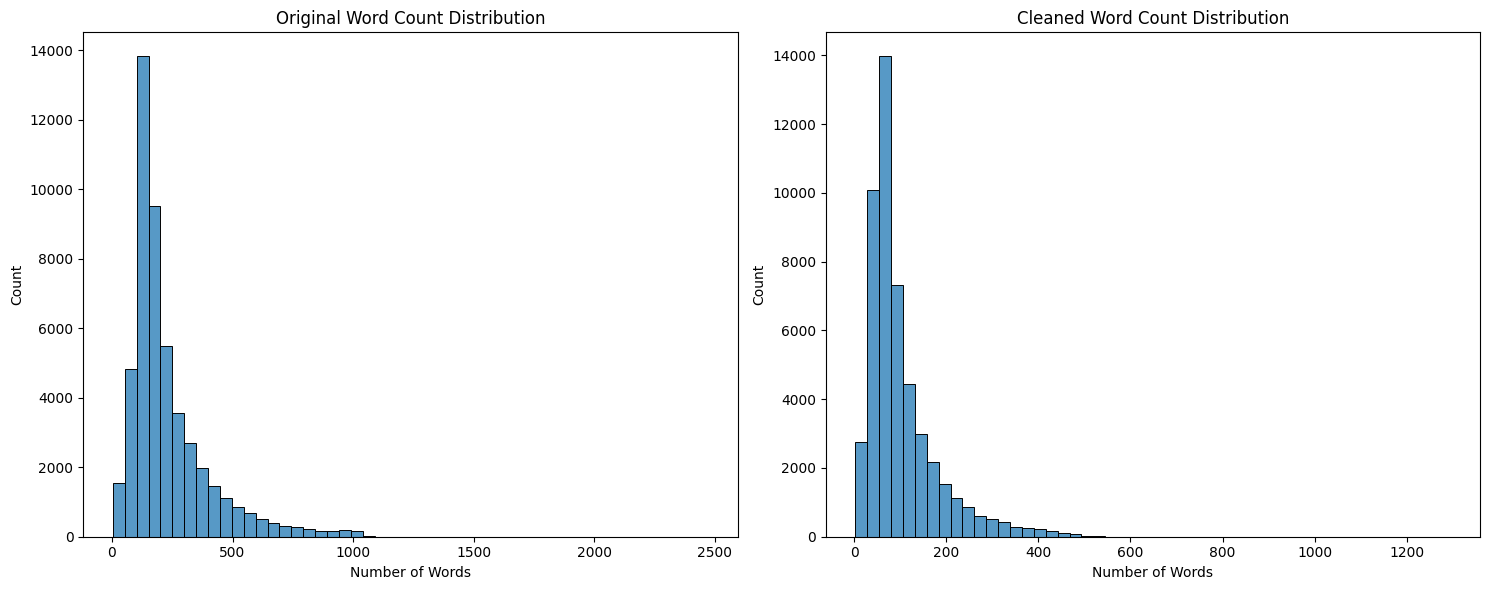


Word Count Statistics Comparison:

Original Reviews:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64

Cleaned Reviews:
count    50000.000000
mean       102.796660
std         78.983581
min          3.000000
25%         54.000000
50%         76.000000
75%        125.000000
max       1294.000000
Name: cleaned_word_count, dtype: float64


In [57]:
# Add cleaned word count column
df['cleaned_word_count'] = df['cleaned_review'].apply(lambda x: len(x.split()))

# Plot comparison of word counts before and after cleaning
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='word_count', bins=50)
plt.title('Original Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='cleaned_word_count', bins=50)
plt.title('Cleaned Word Count Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Compare word count statistics
print("\nWord Count Statistics Comparison:")
print("\nOriginal Reviews:")
print(df['word_count'].describe())
print("\nCleaned Reviews:")
print(df['cleaned_word_count'].describe())

## Vocabulary Analysis


Total unique words in vocabulary: 105161


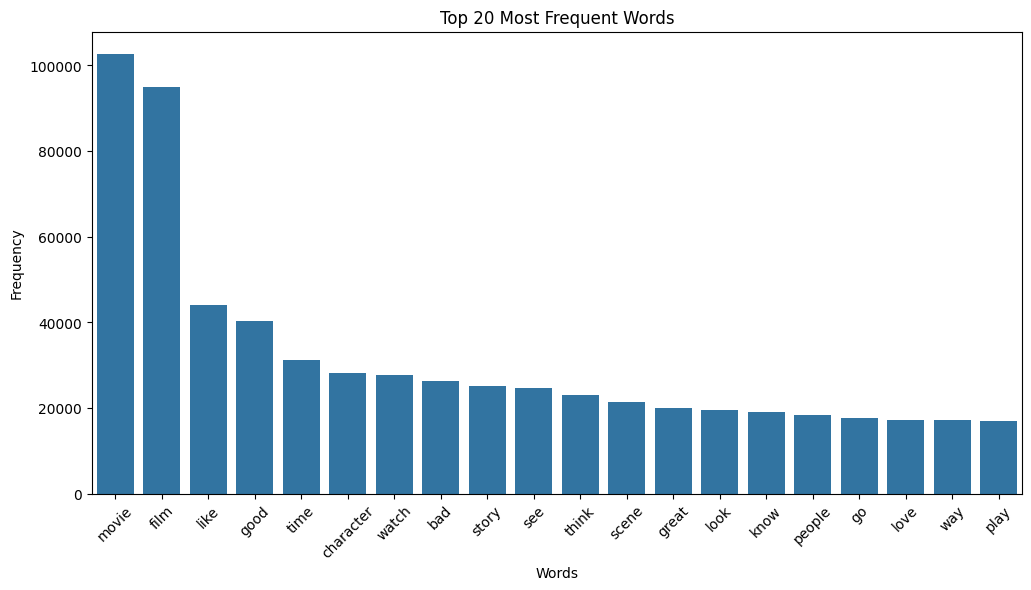

In [58]:
# Create vocabulary from cleaned reviews
vocabulary = set()
for review in df['cleaned_review']:
    vocabulary.update(review.split())

print(f"\nTotal unique words in vocabulary: {len(vocabulary)}")

# Get word frequencies
word_freq = {}
for review in df['cleaned_review']:
    for word in review.split():
        word_freq[word] = word_freq.get(word, 0) + 1

# Sort words by frequency
sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Plot top 20 most frequent words
plt.figure(figsize=(12, 6))
words, freqs = zip(*sorted_word_freq[:20])
sns.barplot(x=list(words), y=list(freqs))
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()